In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import output
from base64 import b64decode
from scipy.ndimage import measurements
from PIL import Image
import os
from google.colab import drive
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
%matplotlib inline

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# ===============================
# 3️⃣ LOAD TRAINED MODEL
# ===============================
model_path = '/content/drive/MyDrive/Face_Attendance_Model/face_recognition_model.keras'
model = tf.keras.models.load_model(model_path)
print("✅ Model loaded successfully!")

# ⚠️ MUST match training order exactly
class_names = ['Abir', 'DIPANKAR', 'Mehedi']

print("Model output shape:", model.output_shape)
print("Total classes:", len(class_names))

✅ Model loaded successfully!
Model output shape: (None, 3)
Total classes: 3


In [ ]:
# ===============================
# 4️⃣ WEBCAM CAPTURE FUNCTION 
# ===============================
def capture_image_from_webcam():
    js_code = """
    async function captureImage() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');
      const canvas = document.createElement('canvas');

      div.style.textAlign = 'center';
      video.style.border = '2px solid black';
      button.textContent = '📸 Capture';
      button.style.fontSize = '20px';
      button.style.marginTop = '10px';

      div.appendChild(video);
      div.appendChild(button);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({ video: true });
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise(resolve => button.onclick = resolve);

      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/png');
    }
    captureImage();
    """

    print("📸 Camera opening below...")
    print("👆 Position your face and click CAPTURE")

    data = output.eval_js(js_code)
    binary = b64decode(data.split(',')[1])

    with open('captured_face.png', 'wb') as f:
        f.write(binary)

    print("✅ Photo captured!")
    return cv2.imread('captured_face.png')




In [ ]:
# ===============================
# 5️⃣ FACE PREPROCESSING
# ===============================
def preprocess_face_for_model(img):
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Improve contrast
    gray = cv2.equalizeHist(gray)

    # Blur + threshold
    blurred = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Find contours
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)

        pad = 30
        x = max(0, x - pad)
        y = max(0, y - pad)
        w = min(w + 2*pad, gray.shape[1] - x)
        h = min(h + 2*pad, gray.shape[0] - y)

        face_crop = gray[y:y+h, x:x+w]
        print("✅ Face cropped using contour")
    else:
        print("⚠️ No contour → using center crop")
        h, w = gray.shape
        size = min(h, w) - 50
        y0 = (h - size) // 2
        x0 = (w - size) // 2
        face_crop = gray[y0:y0+size, x0:x0+size]

    face_resized = cv2.resize(face_crop, (64, 64))
    face_normalized = face_resized.astype("float32") / 255.0
    face_input = face_normalized.reshape(1, 64, 64, 1)

    return face_input, gray, thresh, face_crop, face_resized


📸 Camera opening below...
👆 Position your face and click CAPTURE
✅ Photo captured!
✅ Face cropped using contour
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


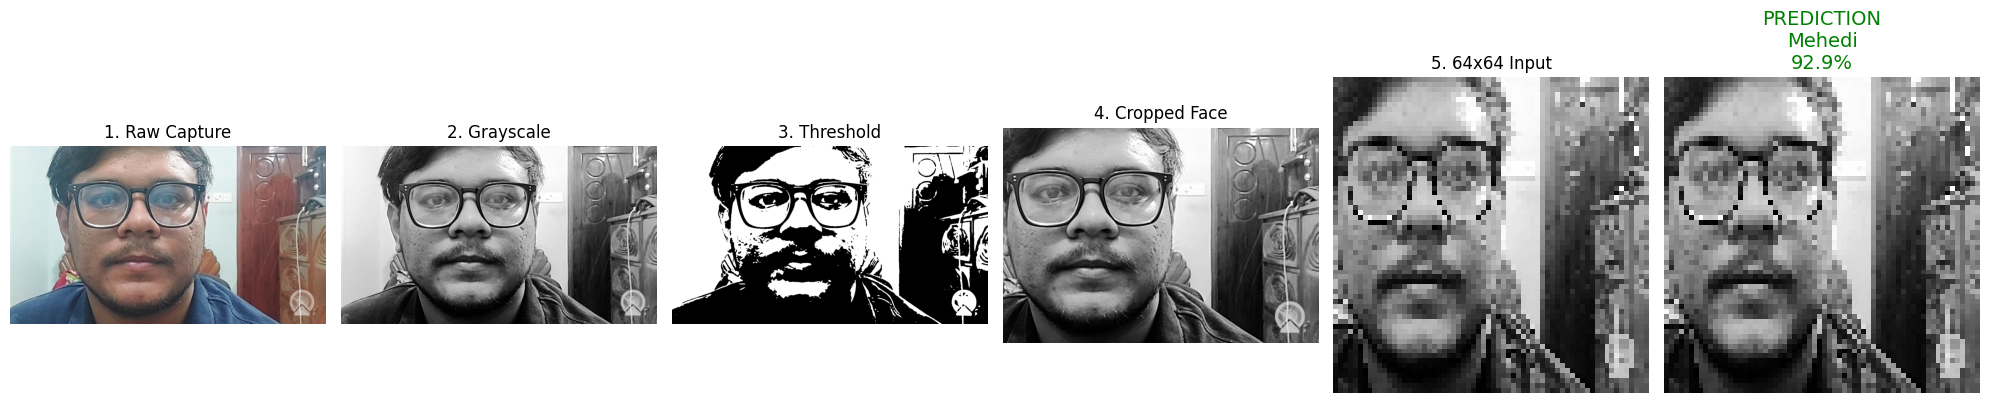

✅ ATTENDANCE MARKED: MEHEDI
Confidence: 92.9%

📋 TIPS:
• Bright lighting
• Face centered & close
• Look straight at camera
• Plain background
• Match training conditions


In [9]:
# ===============================
# 6️⃣ RUN ATTENDANCE
# ===============================
raw_img = capture_image_from_webcam()

try:
    face_input, gray, thresh, cropped, resized = preprocess_face_for_model(raw_img)

    prediction = model.predict(face_input)
    predicted_idx = int(np.argmax(prediction))
    confidence = float(np.max(prediction) * 100)

    if predicted_idx >= len(class_names):
        raise ValueError("❌ Class mismatch between model and class_names")

    predicted_name = class_names[predicted_idx]

    # ===============================
    # DISPLAY PIPELINE
    # ===============================
    plt.figure(figsize=(20, 6))

    plt.subplot(1, 6, 1)
    plt.imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
    plt.title("1. Raw Capture")
    plt.axis('off')

    plt.subplot(1, 6, 2)
    plt.imshow(gray, cmap='gray')
    plt.title("2. Grayscale")
    plt.axis('off')

    plt.subplot(1, 6, 3)
    plt.imshow(thresh, cmap='gray')
    plt.title("3. Threshold")
    plt.axis('off')

    plt.subplot(1, 6, 4)
    plt.imshow(cropped, cmap='gray')
    plt.title("4. Cropped Face")
    plt.axis('off')

    plt.subplot(1, 6, 5)
    plt.imshow(resized, cmap='gray')
    plt.title("5. 64x64 Input")
    plt.axis('off')

    plt.subplot(1, 6, 6)
    plt.imshow(resized, cmap='gray')
    plt.title(
        f"PREDICTION\n{predicted_name}\n{confidence:.1f}%",
        fontsize=14,
        color='green' if confidence > 70 else 'red'
    )
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # ===============================
    # FINAL DECISION
    # ===============================
    if confidence > 70:
        print(f"✅ ATTENDANCE MARKED: {predicted_name.upper()}")
        print(f"Confidence: {confidence:.1f}%")
    else:
        print("❌ Low confidence — try again")

except Exception as e:
    print("⚠️ ERROR:", e)


# ===============================
# 7️⃣ USER TIPS
# ===============================
print("\n📋 TIPS:")
print("• Bright lighting")
print("• Face centered & close")
print("• Look straight at camera")
print("• Plain background")
print("• Match training conditions")